In [118]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from feature_engine.outliers import Winsorizer
from feature_engine.imputation import RandomSampleImputer
from feature_engine import transformation
from scipy import stats
import pylab

In [119]:
df = pd.read_excel(r"C:\Users\my\OneDrive\Desktop\Ecommerce project\5k+ecommerce_dataset (1).xlsx")


In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           5200 non-null   int64         
 1   Age                  4943 non-null   float64       
 2   Gender               5200 non-null   object        
 3   Location             5200 non-null   object        
 4   OrderID              5200 non-null   int64         
 5   ProductID            5200 non-null   int64         
 6   Category             5200 non-null   object        
 7   Price                5200 non-null   float64       
 8   Quantity             5200 non-null   int64         
 9   Discount(%)          5200 non-null   int64         
 10  PaymentMethod        5200 non-null   object        
 11  PurchaseDate         5200 non-null   datetime64[ns]
 12  Rating               4937 non-null   float64       
 13  ShipmentTime(days)   4935 non-nul

In [121]:
df.describe()

,CustomerID,Age,OrderID,ProductID,Price,Quantity,Discount(%),PurchaseDate,Rating,ShipmentTime(days),LastLogin(days),CartAbandonmentRate,ClicksPerSession,Revenue,ChurnRiskScore
count,5200.000000,4943.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200,4937.000000,4935.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000
mean,5487.172308,43.112078,549357.479038,55316.820385,101.515400,2.498654,10.122115,2023-04-15 05:09:12.461538560,3.004456,2.990983,29.468077,0.501952,4.981346,224.564935,0.500429
min,1001.000000,18.000000,100068.000000,10016.000000,-72.080000,1.000000,0.000000,2023-01-01 00:00:00,1.000000,-2.200000,0.000000,0.000000,0.000000,-245.070000,0.000000
25%,3240.000000,30.000000,322609.250000,32399.000000,65.720000,2.000000,5.000000,2023-02-22 06:45:00,2.000000,1.900000,15.000000,0.250000,3.000000,103.945000,0.250000
50%,5498.000000,43.000000,550775.000000,55396.500000,99.745000,2.000000,10.000000,2023-04-15 09:30:00,3.000000,3.000000,30.000000,0.510000,5.000000,189.890000,0.500000
75%,7708.250000,56.000000,773302.750000,78465.750000,134.227500,4.000000,15.000000,2023-06-05 23:00:00,4.000000,4.000000,44.000000,0.760000,6.000000,318.827500,0.760000
max,9996.000000,69.000000,999915.000000,99998.000000,1338.500000,4.000000,20.000000,2023-07-28 07:00:00,5.000000,28.500000,59.000000,1.000000,14.000000,1103.290000,1.000000
std,2574.035095,14.913320,261211.036114,26208.794387,61.451952,1.115557,7.010934,NaN,1.414493,1.619658,17.219618,0.287680,2.217245,160.766707,0.290247


In [122]:
df.isnull().sum()

CustomerID                0
Age                     257
Gender                    0
Location                  0
OrderID                   0
ProductID                 0
Category                  0
Price                     0
Quantity                  0
Discount(%)               0
PaymentMethod             0
PurchaseDate              0
Rating                  263
ShipmentTime(days)      265
LateDelivery              0
CourierPartner            0
LastLogin(days)           0
PurchaseFrequency         0
CartAbandonmentRate       0
ClicksPerSession          0
Revenue                   0
Returned                  0
ReturnReason           1205
ChurnRiskScore            0
dtype: int64

In [123]:
# 1. TYPE CASTING

# Convert ID columns to string (Nominal)
df['CustomerID'] = df['CustomerID'].astype(str)
df['OrderID'] = df['OrderID'].astype(str)
df['ProductID'] = df['ProductID'].astype(str)


In [124]:

# Convert categorical columns to category dtype
cat_cols = [
    'Gender','Location','Category','PaymentMethod','LateDelivery',
    'CourierPartner','Returned','ReturnReason'
]

df[cat_cols] = df[cat_cols].astype('category')


In [125]:
df.dtypes

CustomerID                     object
Age                           float64
Gender                       category
Location                     category
OrderID                        object
ProductID                      object
Category                     category
Price                         float64
Quantity                        int64
Discount(%)                     int64
PaymentMethod                category
PurchaseDate           datetime64[ns]
Rating                        float64
ShipmentTime(days)            float64
LateDelivery                 category
CourierPartner               category
LastLogin(days)                 int64
PurchaseFrequency              object
CartAbandonmentRate           float64
ClicksPerSession                int64
Revenue                       float64
Returned                     category
ReturnReason                 category
ChurnRiskScore                float64
dtype: object

In [126]:
# 2. FIND & REMOVE DUPLICATES

df.duplicated().sum()

np.int64(198)

In [127]:
df = df.drop_duplicates(keep=False)


In [128]:
## show duplicated rows
df[df.duplicated()]


,CustomerID,Age,Gender,Location,OrderID,ProductID,Category,Price,Quantity,Discount(%),...,LateDelivery,CourierPartner,LastLogin(days),PurchaseFrequency,CartAbandonmentRate,ClicksPerSession,Revenue,Returned,ReturnReason,ChurnRiskScore


In [129]:
# 3. MISSING VALUE IMPUTATION
df.isnull().sum()

CustomerID                0
Age                     243
Gender                    0
Location                  0
OrderID                   0
ProductID                 0
Category                  0
Price                     0
Quantity                  0
Discount(%)               0
PaymentMethod             0
PurchaseDate              0
Rating                  237
ShipmentTime(days)      235
LateDelivery              0
CourierPartner            0
LastLogin(days)           0
PurchaseFrequency         0
CartAbandonmentRate       0
ClicksPerSession          0
Revenue                   0
Returned                  0
ReturnReason           1111
ChurnRiskScore            0
dtype: int64

In [130]:
# Mean/Median for numeric columns
median_imputer = SimpleImputer(strategy='median')
df[num_cols] = median_imputer.fit_transform(df[num_cols])


In [131]:
mode_imputer = SimpleImputer(strategy='most_frequent')
df[["ReturnReason"]] = mode_imputer.fit_transform(df[["ReturnReason"]])


In [132]:
cat_cols = ['ReturnReason']
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode())

In [133]:
df.isnull().sum()

CustomerID             0
Age                    0
Gender                 0
Location               0
OrderID                0
ProductID              0
Category               0
Price                  0
Quantity               0
Discount(%)            0
PaymentMethod          0
PurchaseDate           0
Rating                 0
ShipmentTime(days)     0
LateDelivery           0
CourierPartner         0
LastLogin(days)        0
PurchaseFrequency      0
CartAbandonmentRate    0
ClicksPerSession       0
Revenue                0
Returned               0
ReturnReason           0
ChurnRiskScore         0
dtype: int64

In [134]:
# 4. OUTLIER TREATMENT 

num_cols = ['Age','Price','Quantity','Discount(%)','ShipmentTime(days)','Rating',
            'ClicksPerSession','Revenue','CartAbandonmentRate',
            'LastLogin(days)','ChurnRiskScore']

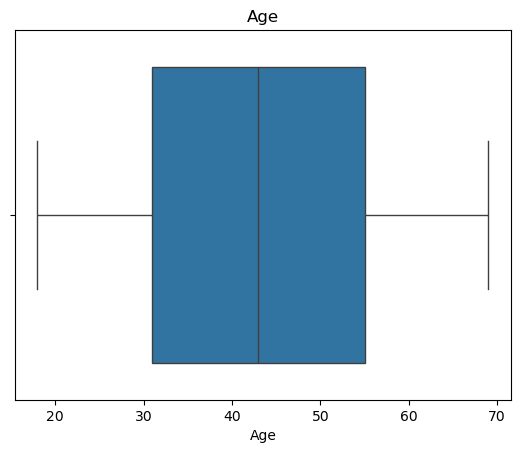

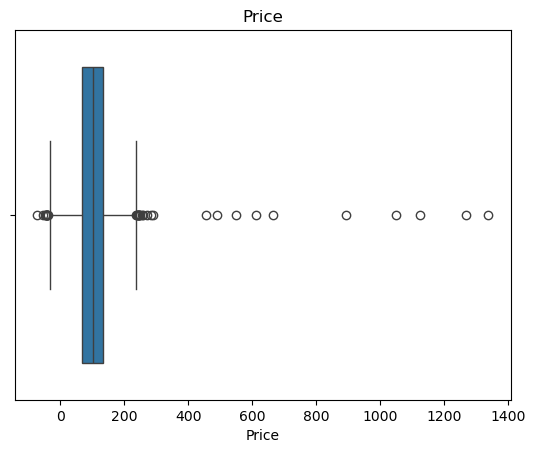

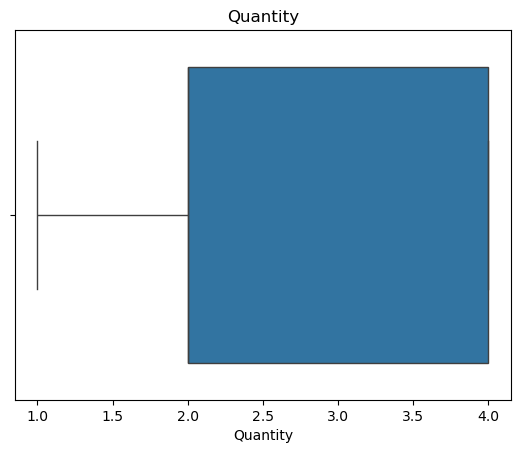

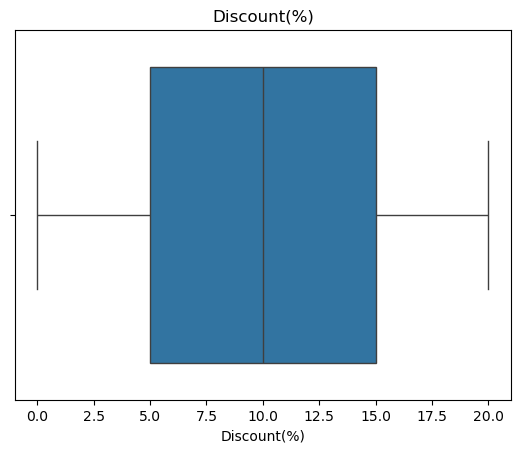

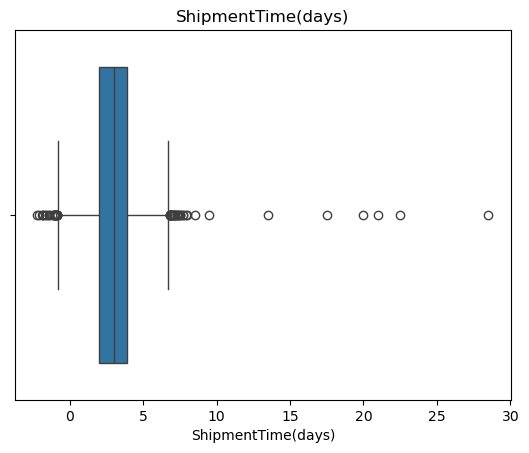

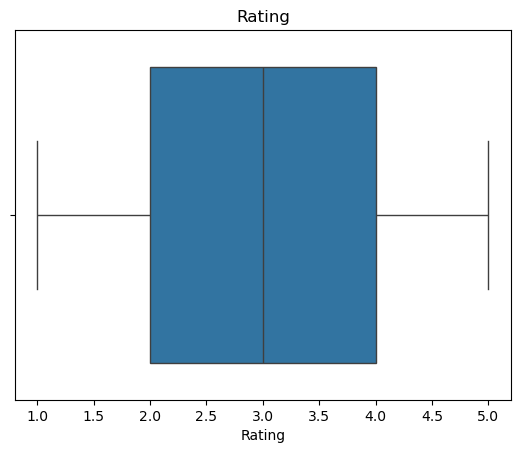

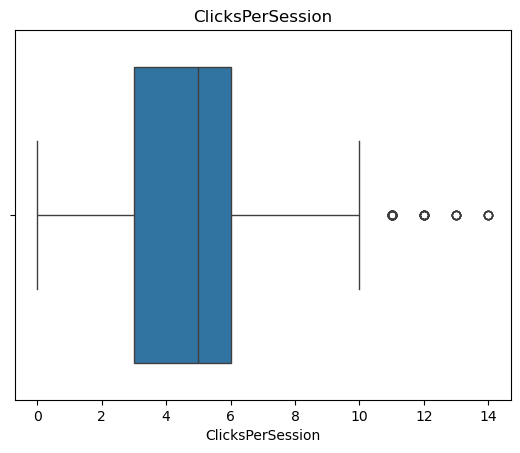

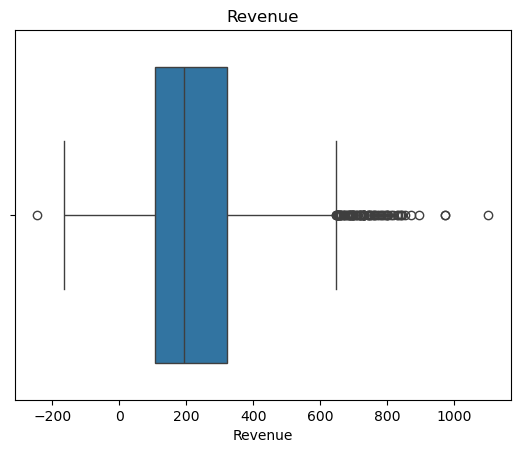

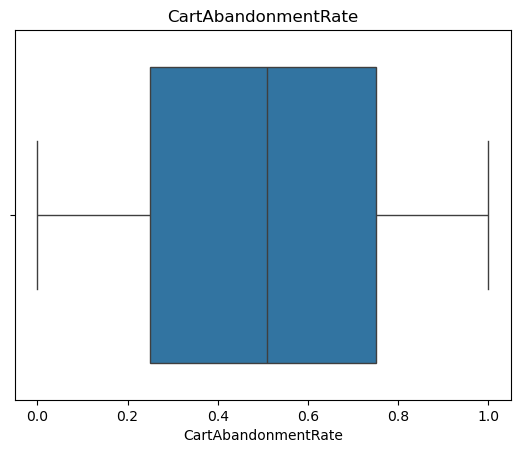

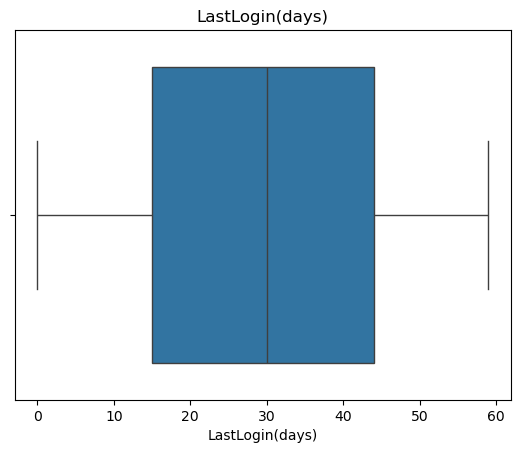

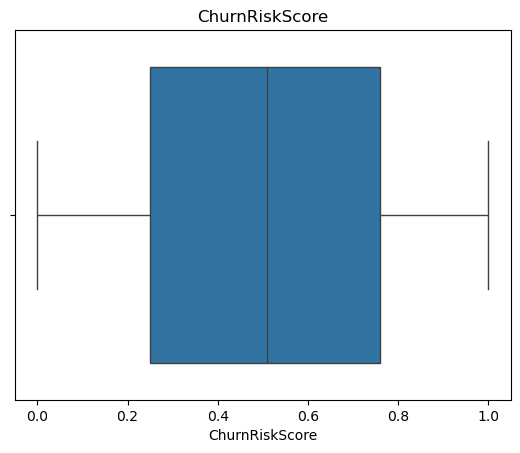

In [135]:
# Boxplots before treatment
for col in num_cols:
    try:
        sns.boxplot(x=df[col])
        plt.title(col)
        plt.show()
    except:
        pass

In [173]:
# Winsorization (IQR method)

winsor = Winsorizer(
    capping_method='iqr',
    tail='both',
    fold=1.5,
    variables=num_cols
)
df[num_cols] = winsor.fit_transform(df[num_cols])

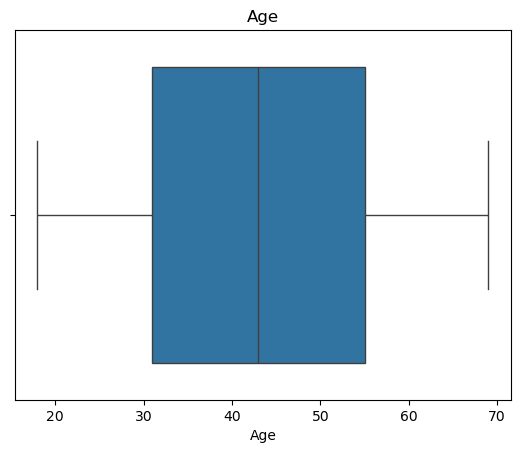

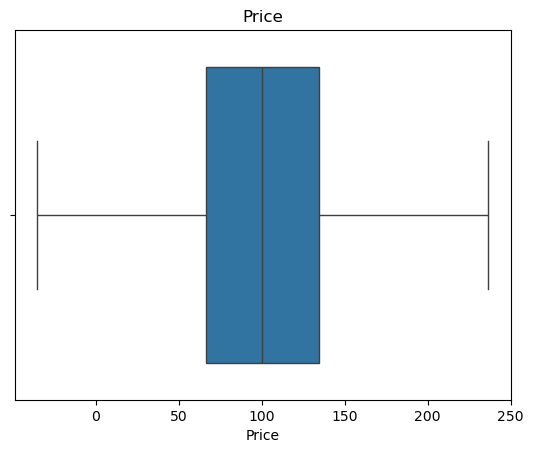

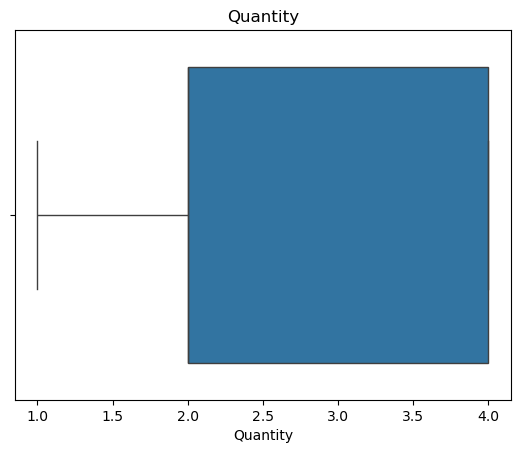

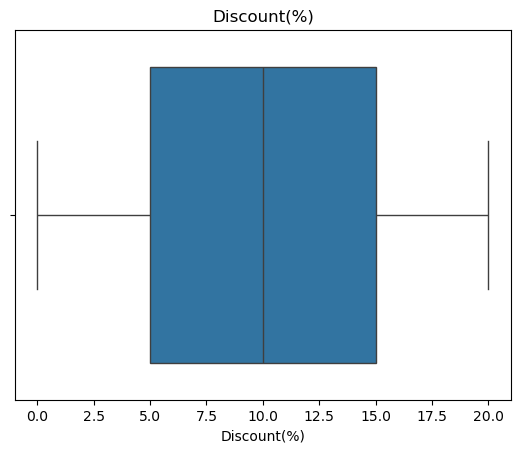

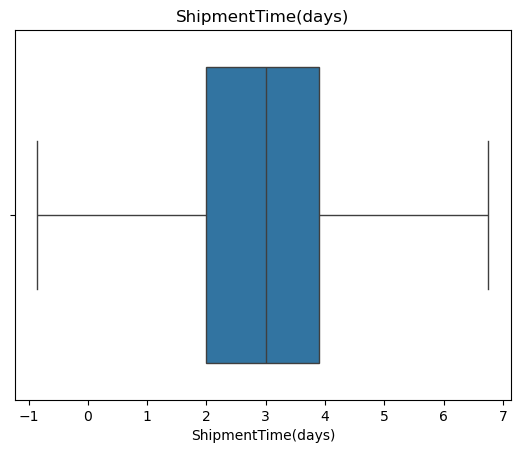

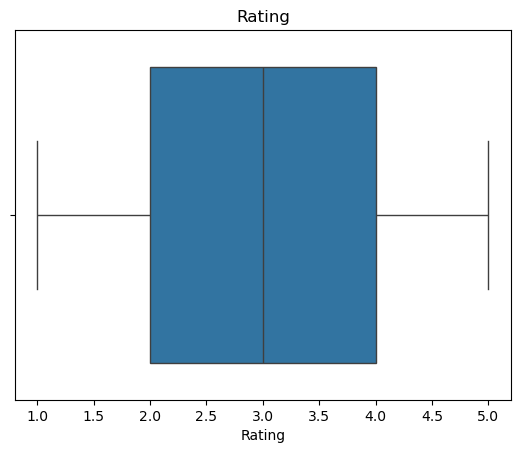

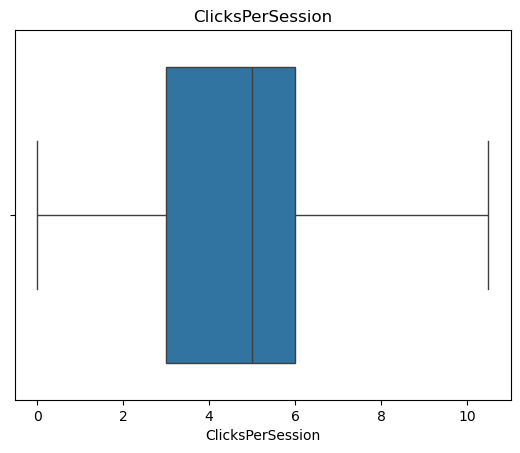

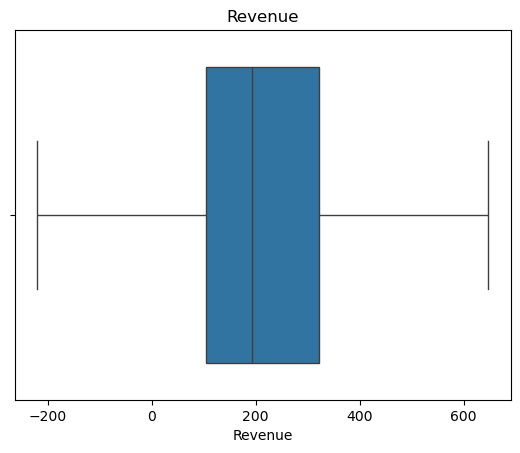

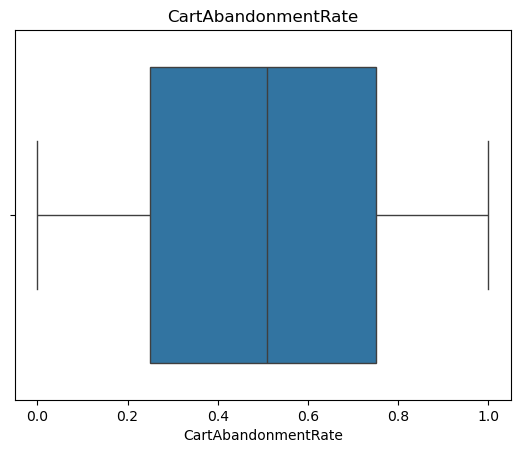

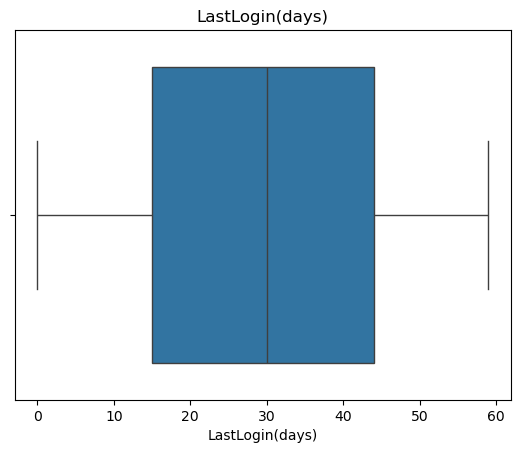

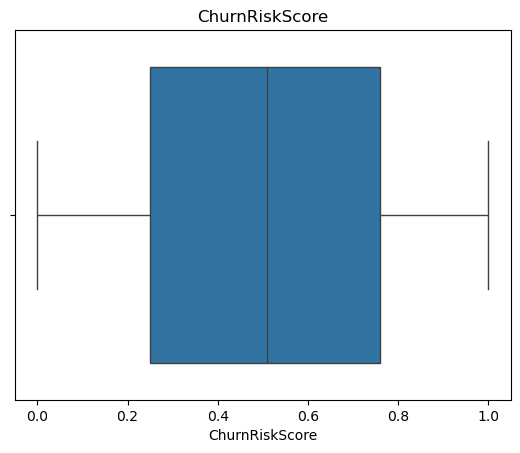

In [174]:
# Boxplots after winsorization
for col in num_cols:
    try:
        sns.boxplot(x=df[col])
        plt.title(col)
        plt.show()
    except:
        pass

In [138]:

# 5. DISCRETIZATION – PRICE BINS

In [139]:
df['Age_Level'] = pd.cut(
    df['Age'],
    bins= 4,
    labels=['Young', 'Adult', 'Middle_aged','Senior'],
    include_lowest=True
)
df['Age_Level'].value_counts()


Age_Level
Adult          1459
Young          1152
Middle_aged    1115
Senior         1078
Name: count, dtype: int64

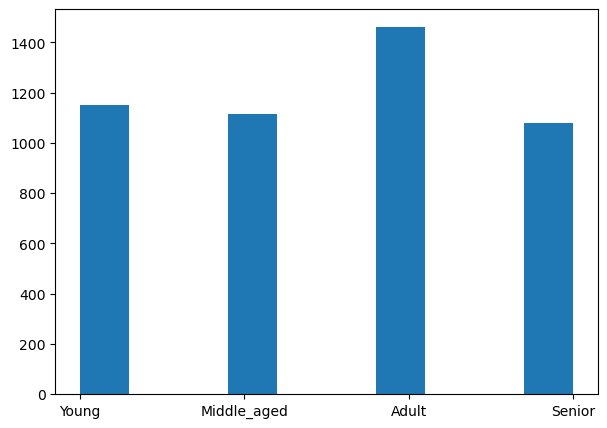

In [140]:
plt.figure(figsize=(7,5))
plt.hist(df['Age_Level'])
plt.show()

In [141]:
df['Price_Level'] = pd.cut(
    df['Price'],
    bins= 4,
    labels=['Low', 'Medium', 'High','Premium'],
    include_lowest=True
)
df['Price_Level'].value_counts()


Price_Level
Medium     1991
High       1953
Premium     442
Low         418
Name: count, dtype: int64

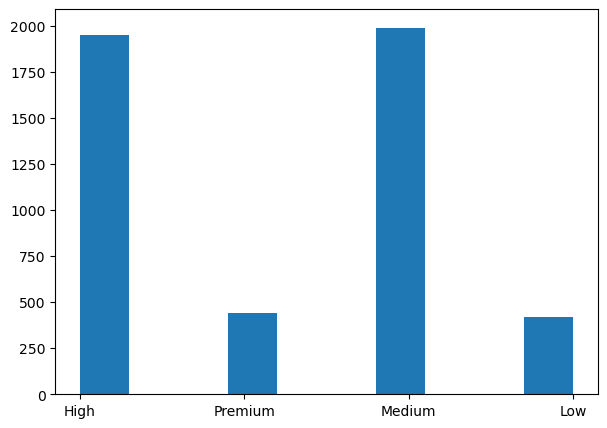

In [142]:
plt.figure(figsize=(7,5))
plt.hist(df['Price_Level'])
plt.show()

In [143]:
df['Price'].value_counts()

Price
 236.50    24
-35.26     11
 61.29      4
 115.69     4
 109.81     4
           ..
 126.08     1
 171.86     1
 194.45     1
 46.60      1
 90.60      1
Name: count, Length: 4140, dtype: int64

In [144]:
df['Quantity_Level'] = pd.cut(
    df['Quantity'],
    bins= 4,
    labels=['very low','Low', 'Medium', 'High'],
    include_lowest=True
)
df['Quantity_Level'].value_counts()



Quantity_Level
Low         1255
High        1214
Medium      1178
very low    1157
Name: count, dtype: int64

In [145]:
df['Quantity'].value_counts()


Quantity
2.0    1255
4.0    1214
3.0    1178
1.0    1157
Name: count, dtype: int64

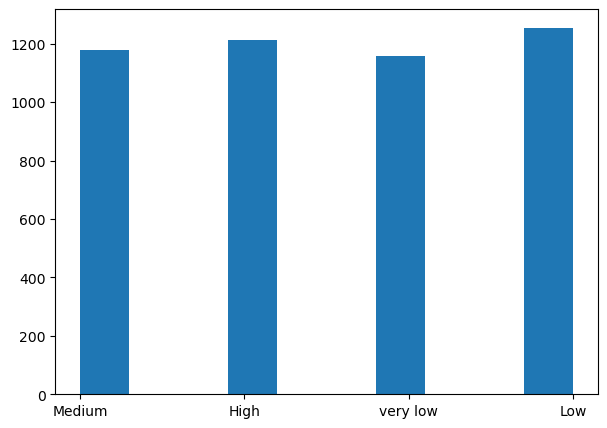

In [146]:
plt.figure(figsize=(7,5))
plt.hist(df['Quantity_Level'])
plt.show()

In [147]:
df['Discount(%)_Level'] = pd.cut(
    df['Discount(%)'],
    bins= 4,
    labels=['No_Discount','Low', 'Medium', 'High'],
    include_lowest=True
)
df['Discount(%)_Level'].value_counts()


Discount(%)_Level
No_Discount    1903
Medium          997
High            964
Low             940
Name: count, dtype: int64

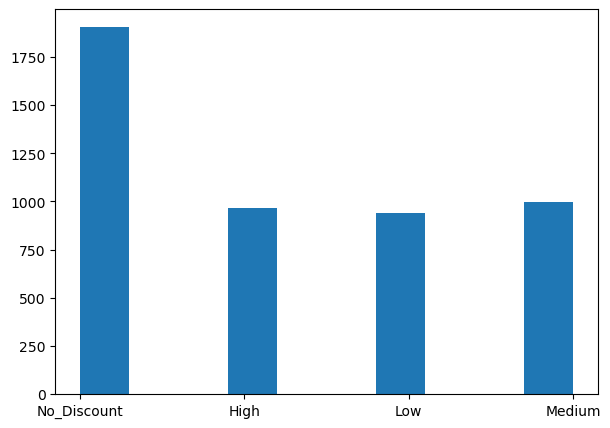

In [148]:
plt.figure(figsize=(7,5))
plt.hist(df['Discount(%)_Level'])
plt.show()

In [149]:
df['ShipmentTime(days)_Level'] = pd.cut(
    df['ShipmentTime(days)'],
    bins= 3,
    labels=['Fast', 'Normal', 'Slow'],
    include_lowest=True
)
df['ShipmentTime(days)_Level'].value_counts()


ShipmentTime(days)_Level
Normal    3074
Slow       886
Fast       844
Name: count, dtype: int64

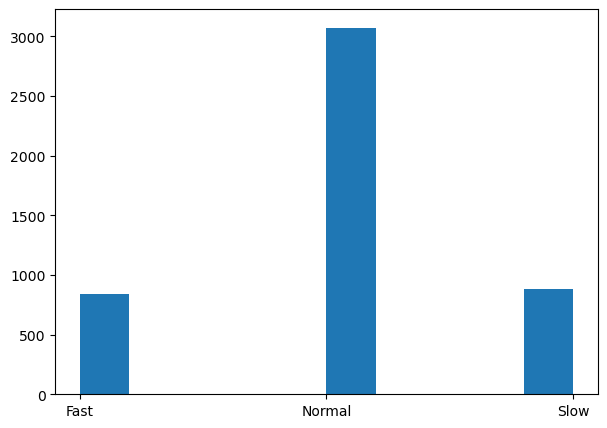

In [150]:
plt.figure(figsize=(7,5))
plt.hist(df['ShipmentTime(days)_Level'])
plt.show()

In [151]:
df['Rating_Level'] = pd.cut(
    df['Rating'],
    bins= 3,
    labels=['Poor', 'Average', 'Excellent'],
    include_lowest=True
)
df['Rating_Level'].value_counts()


Rating_Level
Poor         1823
Excellent    1814
Average      1167
Name: count, dtype: int64

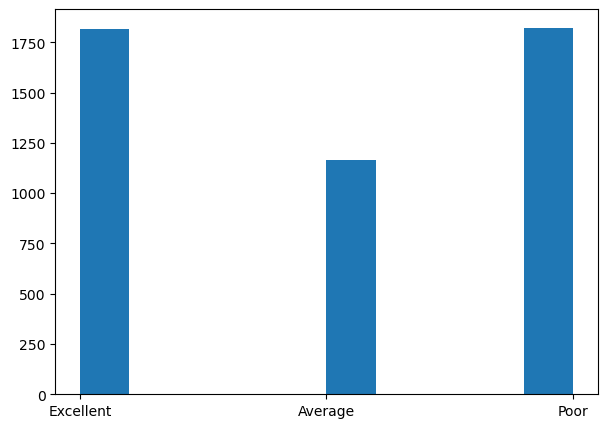

In [152]:
plt.figure(figsize=(7,5))
plt.hist(df['Rating_Level'])
plt.show()

In [153]:
df['Revenue_Level'] = pd.cut(
    df['Revenue'],
    bins= 4,
    labels=['Low', 'Medium','High','very high'],
    include_lowest=True
)
df['Revenue_Level'].value_counts()


Revenue_Level
Medium       2536
High         1611
very high     562
Low            95
Name: count, dtype: int64

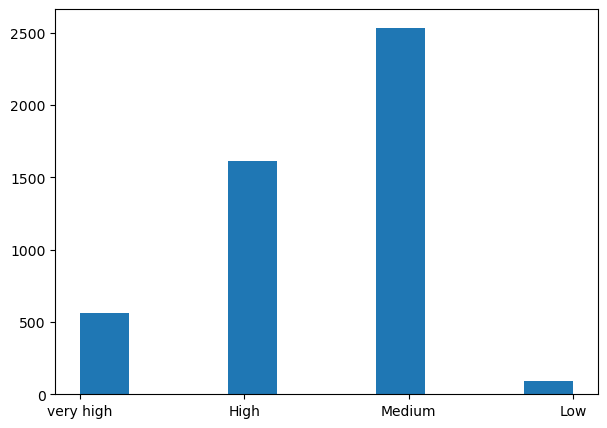

In [154]:
plt.figure(figsize=(7,5))
plt.hist(df['Revenue_Level'])
plt.show()

In [155]:
df['LastLogin(days)_Level'] = pd.cut(
    df['LastLogin(days)'],
    bins= 4,
    labels=['Very_Recent', 'Recent', 'Inactive','Dormant'],
    include_lowest=True
)
df['LastLogin(days)_Level'].value_counts()


LastLogin(days)_Level
Inactive       1256
Recent         1202
Very_Recent    1197
Dormant        1149
Name: count, dtype: int64

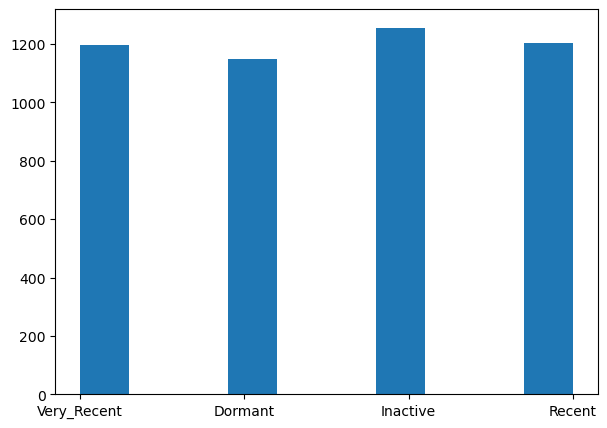

In [156]:
plt.figure(figsize=(7,5))
plt.hist(df['LastLogin(days)_Level'])
plt.show()

In [157]:
df['ChurnRiskScore_Level'] = pd.cut(
    df['ChurnRiskScore'],
    bins= 3,
    labels=['Low_Risk', 'Medium_Risk', 'High_Risk'],
    include_lowest=True
)
df['ChurnRiskScore_Level'].value_counts()


ChurnRiskScore_Level
High_Risk      1656
Low_Risk       1631
Medium_Risk    1517
Name: count, dtype: int64

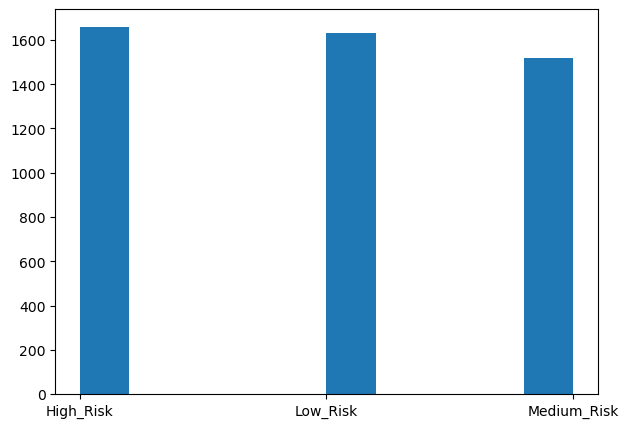

In [158]:
plt.figure(figsize=(7,5))
plt.hist(df['ChurnRiskScore_Level'])
plt.show()

In [159]:
## 6 .  Label Encoding
LE = LabelEncoder()

df['Gender_LE'] = LE.fit_transform(df['Gender'])
df['Location_LE'] = LE.fit_transform(df['Location'])
df['Category_LE'] = LE.fit_transform(df['Category'])
df


,CustomerID,Age,Gender,Location,OrderID,ProductID,Category,Price,Quantity,Discount(%),...,Quantity_Level,Discount(%)_Level,ShipmentTime(days)_Level,Rating_Level,Revenue_Level,LastLogin(days)_Level,ChurnRiskScore_Level,Gender_LE,Location_LE,Category_LE
0,8270,30.0,Other,Suburban,924765,63105,Beauty,153.41,3.0,0.0,...,Medium,No_Discount,Fast,Excellent,very high,Very_Recent,High_Risk,2,1,0
1,1860,53.0,Male,Urban,366579,73436,Clothing,145.59,3.0,20.0,...,Medium,High,Fast,Average,High,Very_Recent,Low_Risk,1,2,2
2,6390,30.0,Male,Rural,924850,79579,Books,198.35,4.0,10.0,...,High,Low,Normal,Excellent,very high,Very_Recent,Medium_Risk,1,0,1
3,6191,29.0,Female,Rural,157955,24242,Clothing,78.15,1.0,0.0,...,very low,No_Discount,Slow,Average,Medium,Very_Recent,High_Risk,0,0,2
4,6734,54.0,Male,Suburban,421651,37133,Beauty,209.66,2.0,10.0,...,Low,Low,Slow,Average,High,Very_Recent,Low_Risk,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4997,2140,33.0,Female,Suburban,858707,94067,Clothing,165.09,4.0,5.0,...,High,No_Discount,Normal,Poor,very high,Dormant,Medium_Risk,0,1,2
4998,6730,58.0,Male,Rural,263073,19109,Home,43.83,1.0,0.0,...,very low,No_Discount,Normal,Poor,Medium,Dormant,High_Risk,1,0,4
4999,8465,51.0,Female,Rural,240401,36842,Home,83.72,1.0,15.0,...,very low,Medium,Normal,Poor,Medium,Inactive,High_Risk,0,0,4
5146,8164,40.0,Male,Suburban,600642,50431,Beauty,93.83,4.0,10.0,...,High,Low,Fast,Average,High,Dormant,Low_Risk,1,1,0


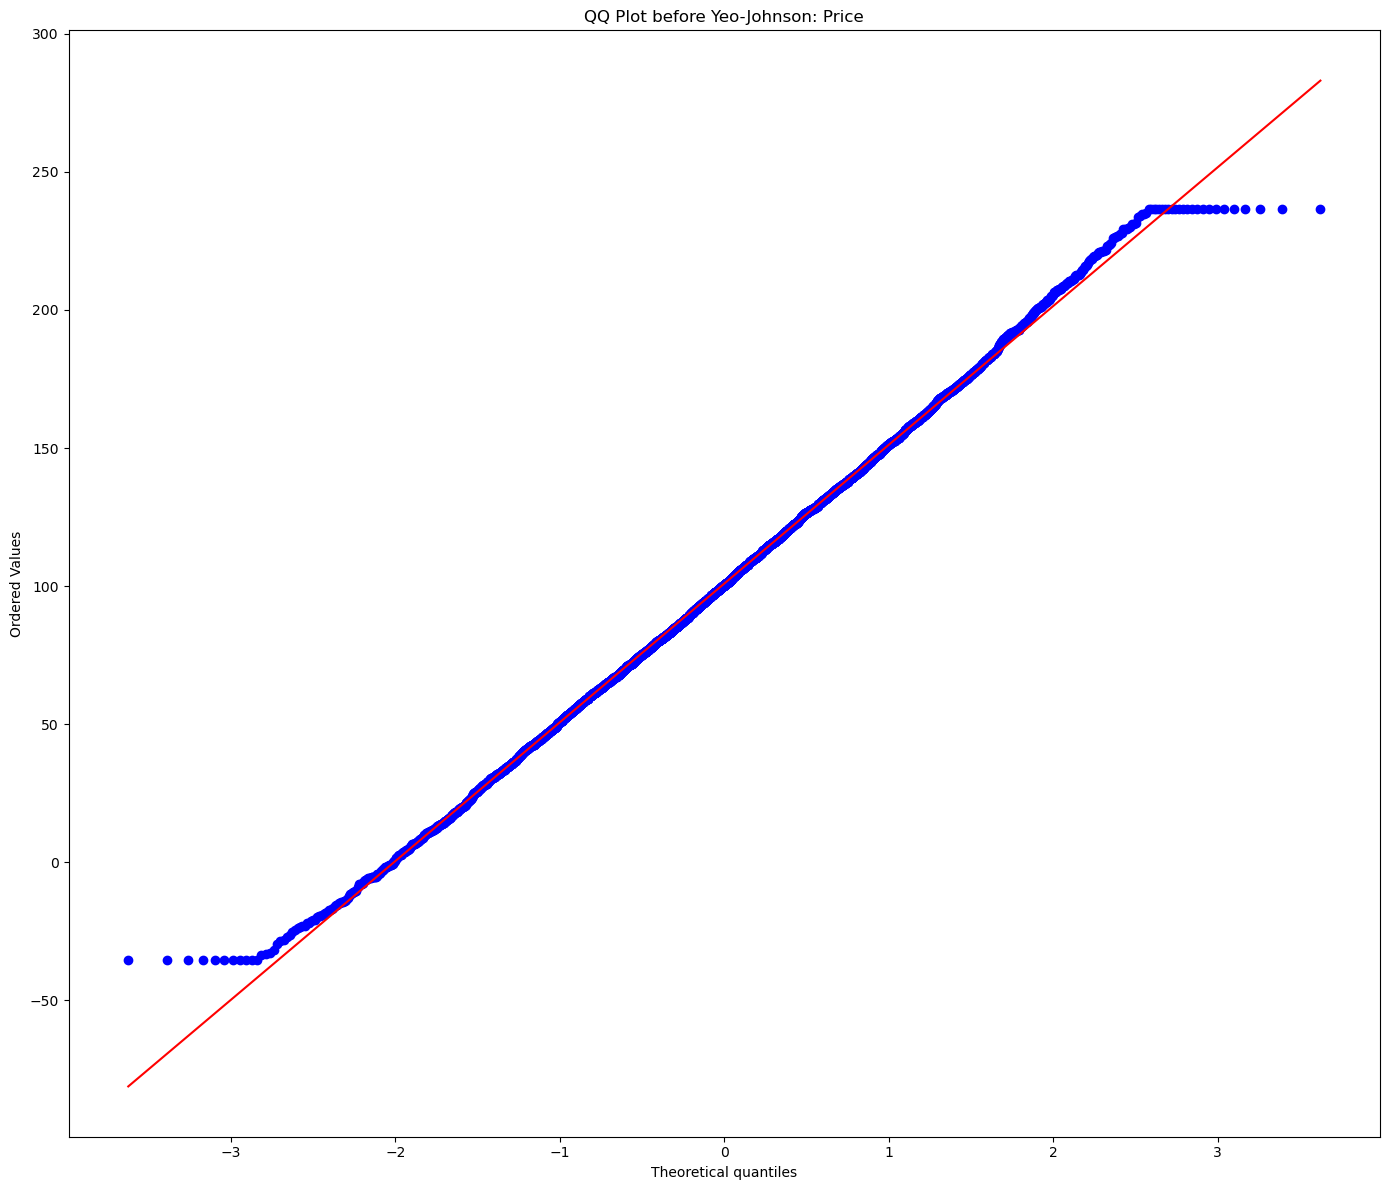

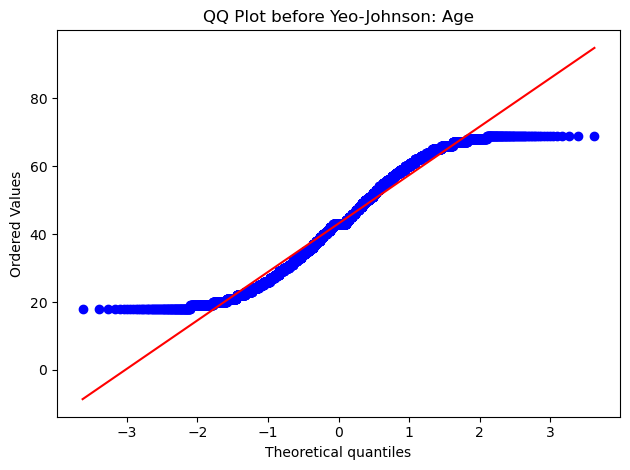

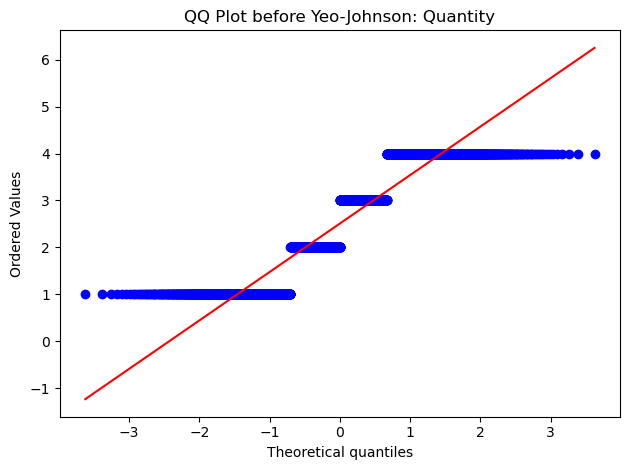

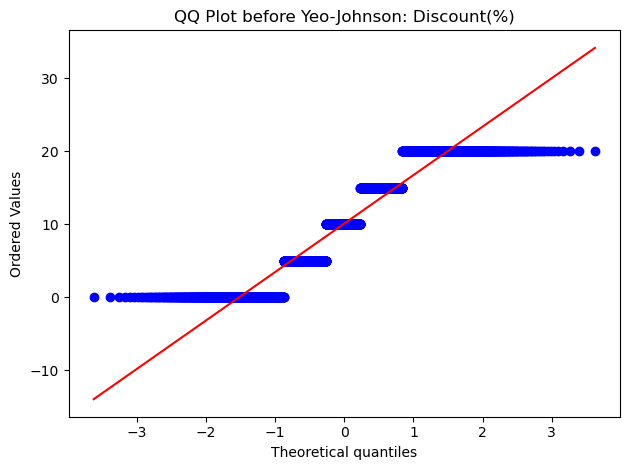

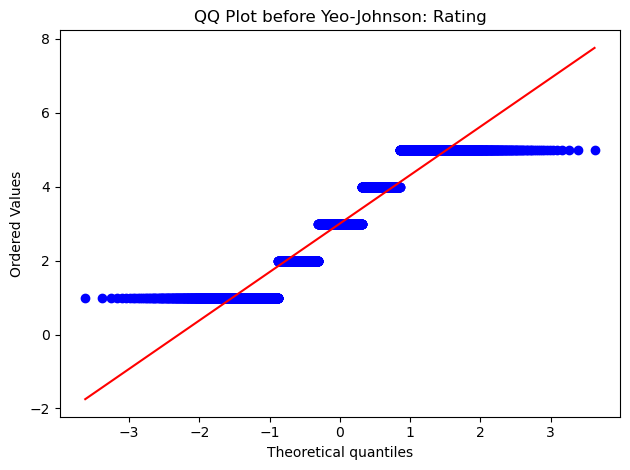

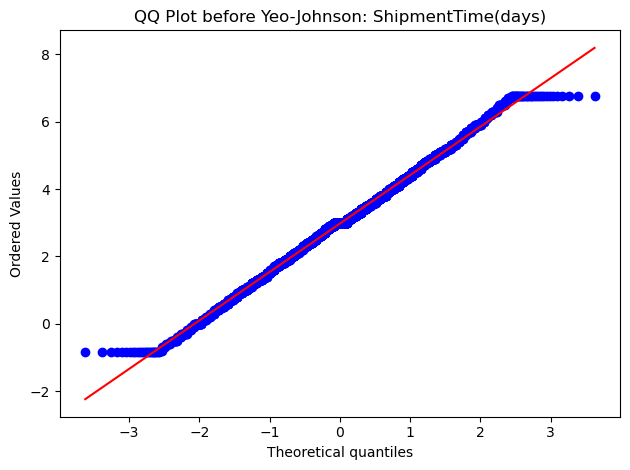

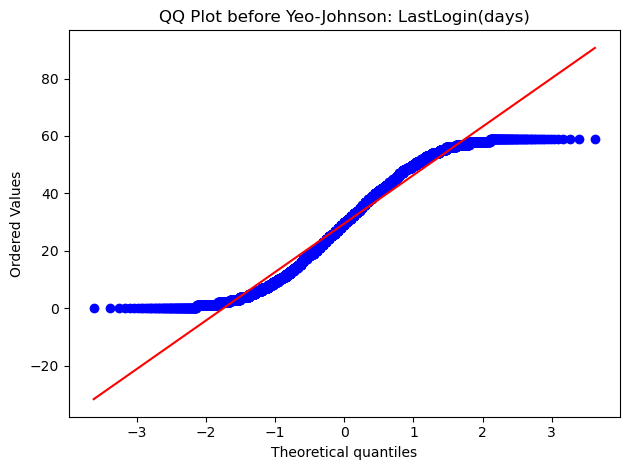

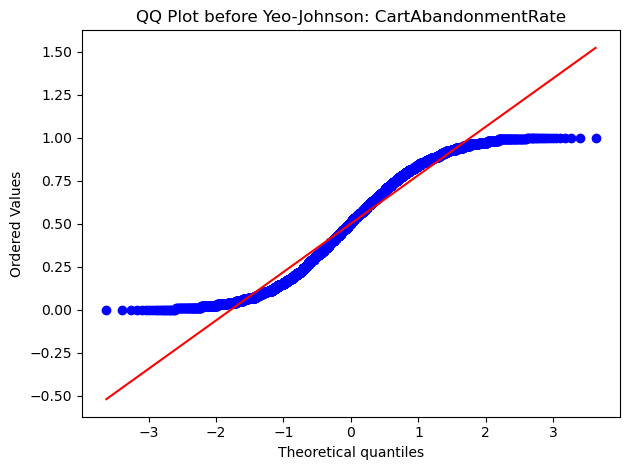

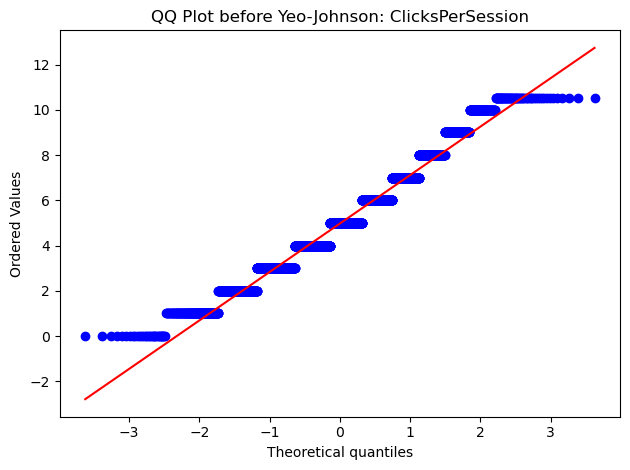

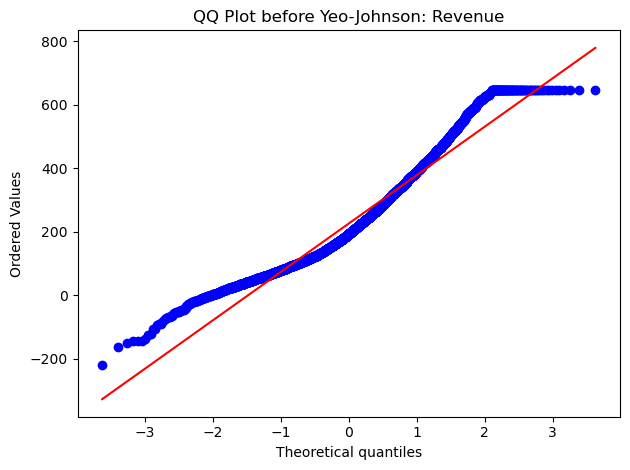

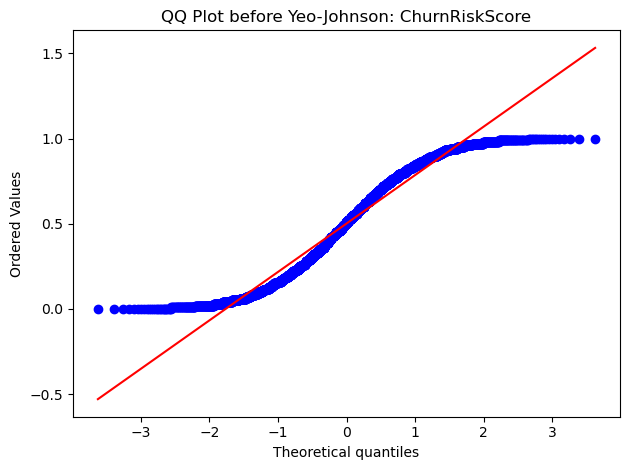

In [160]:
# 7. QQ PLOTS + TRANSFORMATIONS (Normality check)

#QQ Plots before Transformation


pt_cols = ['Price','Age','Quantity','Discount(%)','Rating','ShipmentTime(days)','LastLogin(days)','CartAbandonmentRate',
           'ClicksPerSession','Revenue','ChurnRiskScore',]

plt.figure(figsize=(14,12))

for i, col in enumerate(pt_cols, 1):
    stats.probplot(df[col], dist='norm', plot=plt)
    plt.title(f"QQ Plot before Yeo-Johnson: {col}", fontsize=12)

    plt.tight_layout()
    plt.show()


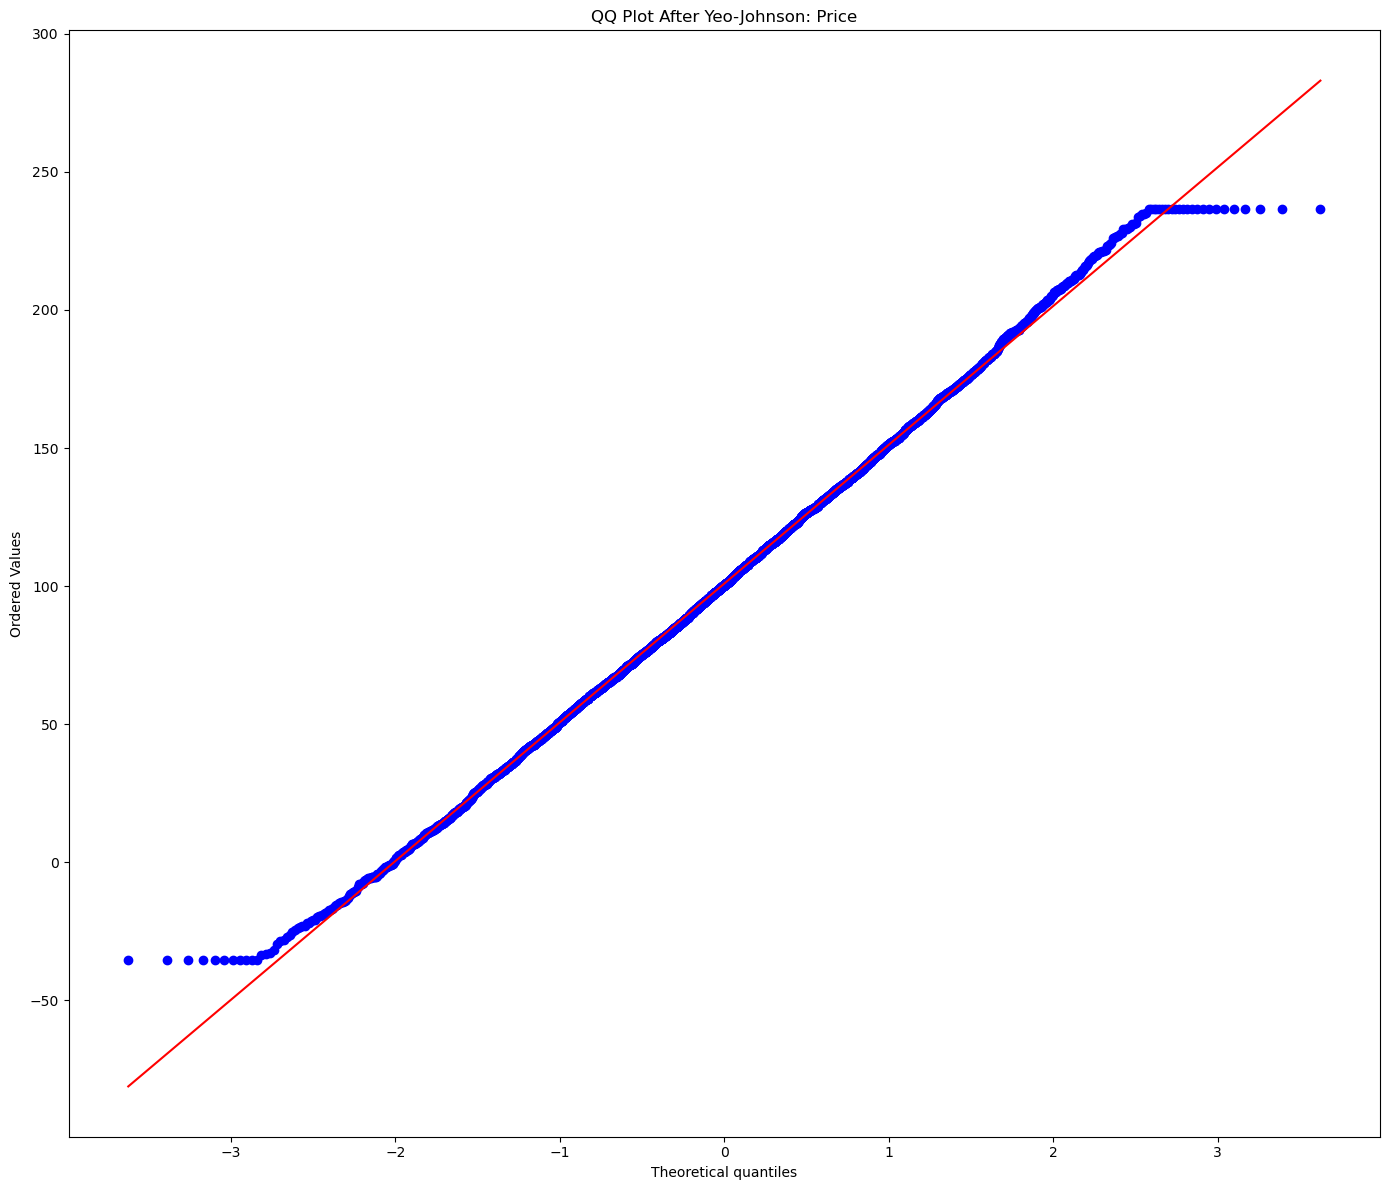

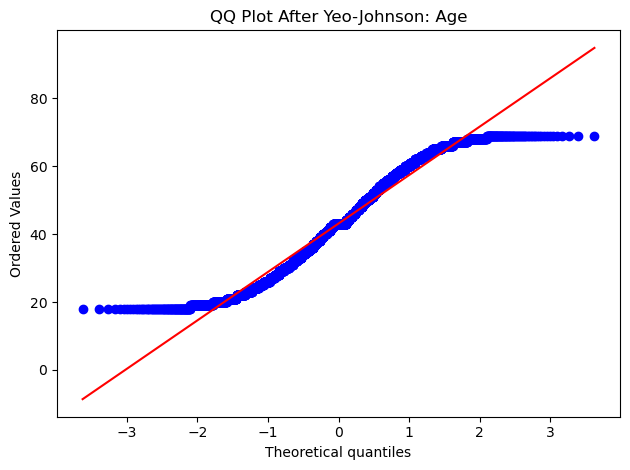

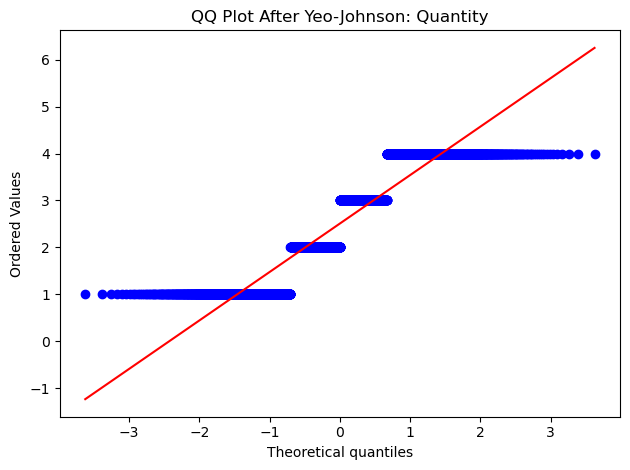

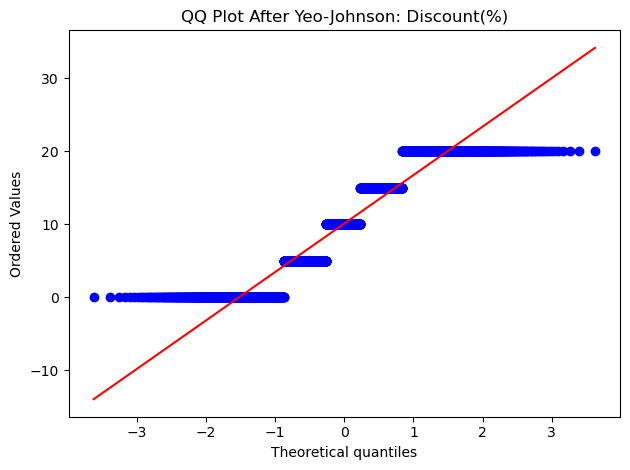

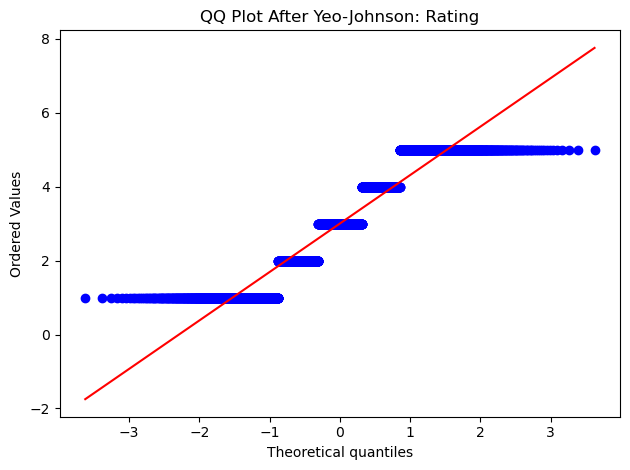

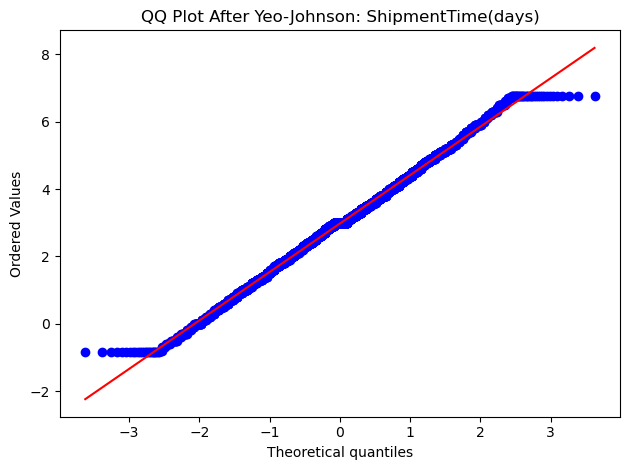

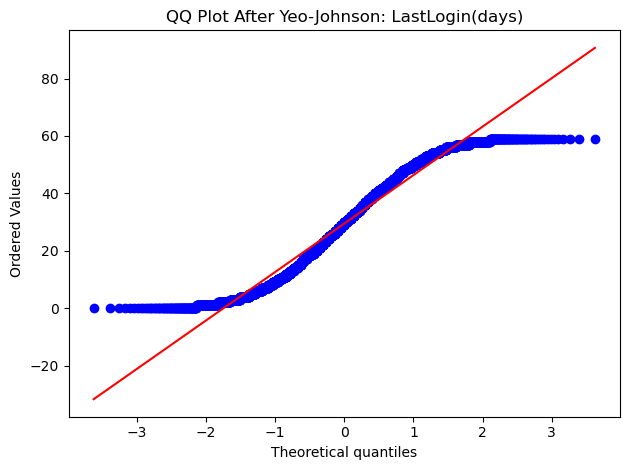

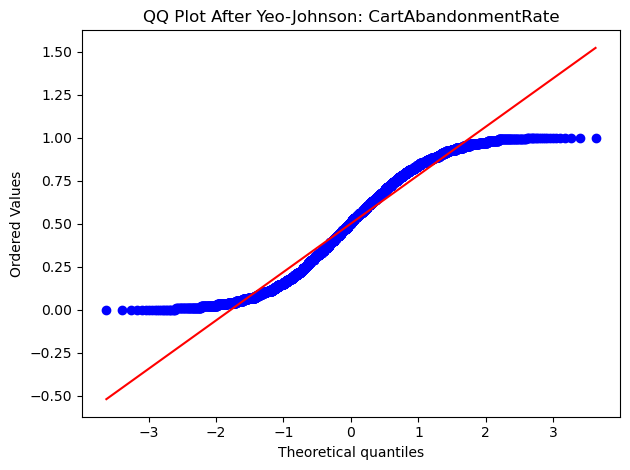

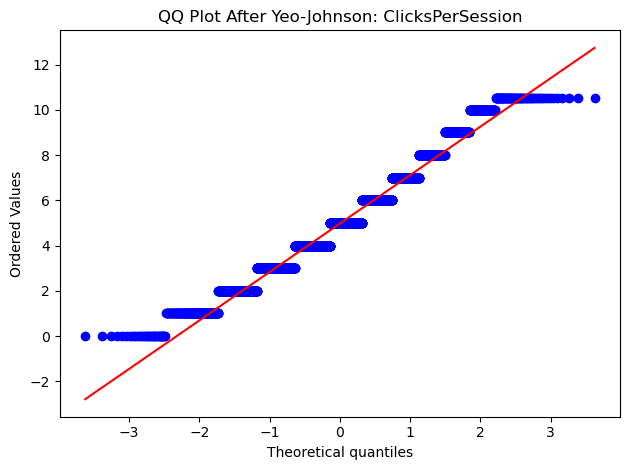

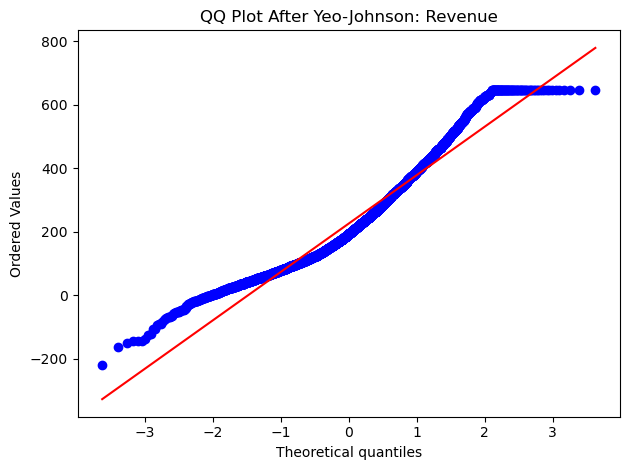

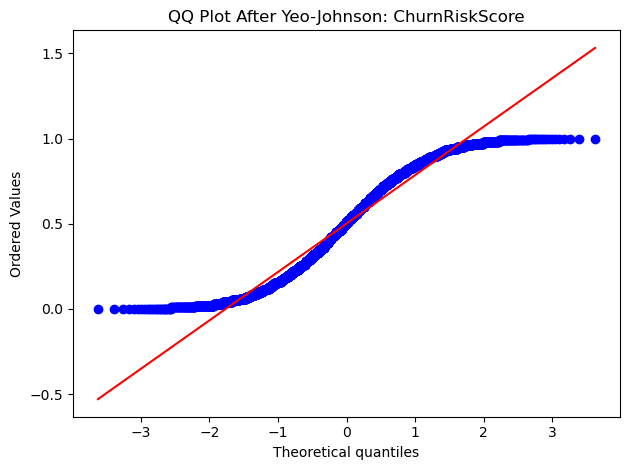

In [161]:
#QQ Plots after Transformation


pt_cols = ['Price','Age','Quantity','Discount(%)','Rating','ShipmentTime(days)','LastLogin(days)','CartAbandonmentRate',
           'ClicksPerSession','Revenue','ChurnRiskScore',]

plt.figure(figsize=(14,12))

for i, col in enumerate(pt_cols, 1):
    stats.probplot(df[col], dist='norm', plot=plt)
    plt.title(f"QQ Plot After Yeo-Johnson: {col}", fontsize=12)
    plt.tight_layout()
    plt.show()

In [162]:
# 9. STANDARDIZATION & SCALING

scaler = StandardScaler()
df_std = pd.DataFrame(scaler.fit_transform(df[num_cols]), columns=num_cols)
df_std.head()

,Age,Price,Quantity,Discount(%),ShipmentTime(days),Rating,ClicksPerSession,Revenue,CartAbandonmentRate,LastLogin(days),ChurnRiskScore
0,-0.902322,1.044668,0.440761,-1.438930,-1.649587,1.439768,1.394047,1.500630,-1.145939,-1.129732,1.197724
1,0.681817,0.889012,0.440761,1.406648,-1.024609,-0.003907,-0.448573,0.792914,1.074486,-1.651492,-1.104139
2,-0.902322,1.939196,1.339877,-0.016141,-0.121863,0.717931,-1.830538,2.696557,0.207132,-0.897838,0.338820
3,-0.971198,-0.453376,-1.357470,-1.438930,1.197534,-0.003907,-0.909228,-0.939620,0.831627,-0.897838,0.991587
4,0.750693,2.164320,-0.458354,-0.016141,2.030838,-0.003907,0.933392,0.971551,-1.007163,-1.477572,-1.722550


In [163]:
minmax = MinMaxScaler()
df_norm = pd.DataFrame(minmax.fit_transform(df[num_cols]), columns=num_cols)
df

,CustomerID,Age,Gender,Location,OrderID,ProductID,Category,Price,Quantity,Discount(%),...,Quantity_Level,Discount(%)_Level,ShipmentTime(days)_Level,Rating_Level,Revenue_Level,LastLogin(days)_Level,ChurnRiskScore_Level,Gender_LE,Location_LE,Category_LE
0,8270,30.0,Other,Suburban,924765,63105,Beauty,153.41,3.0,0.0,...,Medium,No_Discount,Fast,Excellent,very high,Very_Recent,High_Risk,2,1,0
1,1860,53.0,Male,Urban,366579,73436,Clothing,145.59,3.0,20.0,...,Medium,High,Fast,Average,High,Very_Recent,Low_Risk,1,2,2
2,6390,30.0,Male,Rural,924850,79579,Books,198.35,4.0,10.0,...,High,Low,Normal,Excellent,very high,Very_Recent,Medium_Risk,1,0,1
3,6191,29.0,Female,Rural,157955,24242,Clothing,78.15,1.0,0.0,...,very low,No_Discount,Slow,Average,Medium,Very_Recent,High_Risk,0,0,2
4,6734,54.0,Male,Suburban,421651,37133,Beauty,209.66,2.0,10.0,...,Low,Low,Slow,Average,High,Very_Recent,Low_Risk,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4997,2140,33.0,Female,Suburban,858707,94067,Clothing,165.09,4.0,5.0,...,High,No_Discount,Normal,Poor,very high,Dormant,Medium_Risk,0,1,2
4998,6730,58.0,Male,Rural,263073,19109,Home,43.83,1.0,0.0,...,very low,No_Discount,Normal,Poor,Medium,Dormant,High_Risk,1,0,4
4999,8465,51.0,Female,Rural,240401,36842,Home,83.72,1.0,15.0,...,very low,Medium,Normal,Poor,Medium,Inactive,High_Risk,0,0,4
5146,8164,40.0,Male,Suburban,600642,50431,Beauty,93.83,4.0,10.0,...,High,Low,Fast,Average,High,Dormant,Low_Risk,1,1,0


In [164]:
robust = RobustScaler()
df_robust = pd.DataFrame(robust.fit_transform(df[num_cols]), columns=num_cols)
df


,CustomerID,Age,Gender,Location,OrderID,ProductID,Category,Price,Quantity,Discount(%),...,Quantity_Level,Discount(%)_Level,ShipmentTime(days)_Level,Rating_Level,Revenue_Level,LastLogin(days)_Level,ChurnRiskScore_Level,Gender_LE,Location_LE,Category_LE
0,8270,30.0,Other,Suburban,924765,63105,Beauty,153.41,3.0,0.0,...,Medium,No_Discount,Fast,Excellent,very high,Very_Recent,High_Risk,2,1,0
1,1860,53.0,Male,Urban,366579,73436,Clothing,145.59,3.0,20.0,...,Medium,High,Fast,Average,High,Very_Recent,Low_Risk,1,2,2
2,6390,30.0,Male,Rural,924850,79579,Books,198.35,4.0,10.0,...,High,Low,Normal,Excellent,very high,Very_Recent,Medium_Risk,1,0,1
3,6191,29.0,Female,Rural,157955,24242,Clothing,78.15,1.0,0.0,...,very low,No_Discount,Slow,Average,Medium,Very_Recent,High_Risk,0,0,2
4,6734,54.0,Male,Suburban,421651,37133,Beauty,209.66,2.0,10.0,...,Low,Low,Slow,Average,High,Very_Recent,Low_Risk,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4997,2140,33.0,Female,Suburban,858707,94067,Clothing,165.09,4.0,5.0,...,High,No_Discount,Normal,Poor,very high,Dormant,Medium_Risk,0,1,2
4998,6730,58.0,Male,Rural,263073,19109,Home,43.83,1.0,0.0,...,very low,No_Discount,Normal,Poor,Medium,Dormant,High_Risk,1,0,4
4999,8465,51.0,Female,Rural,240401,36842,Home,83.72,1.0,15.0,...,very low,Medium,Normal,Poor,Medium,Inactive,High_Risk,0,0,4
5146,8164,40.0,Male,Suburban,600642,50431,Beauty,93.83,4.0,10.0,...,High,Low,Fast,Average,High,Dormant,Low_Risk,1,1,0


In [165]:
print("Original DF:", df.shape)

Original DF: (4804, 36)


In [166]:
print("Encoded columns shape:", df[['Gender_LE','Location_LE','Category_LE']].shape)


Encoded columns shape: (4804, 3)


In [167]:
print("Standardized DF:", df_std.shape)

Standardized DF: (4804, 11)


In [168]:
print("Normalized DF:", df_norm.shape)

Normalized DF: (4804, 11)


In [169]:
print("Robust Scaled DF:", df_robust.shape)


Robust Scaled DF: (4804, 11)


In [170]:
import os

In [177]:
df.to_excel(
    r"C:\Users\my\OneDrive\Desktop\Ecommerce project\python code\ecommerce_data_preprocessing.xlsx",
    index=False
)

In [172]:
## for scaling data 
df_scaled = pd.DataFrame(df_std, columns=num_cols)
df_scaled.to_excel(
     r"C:\Users\my\OneDrive\Desktop\Ecommerce project\scaled data.xlsx",
    index=False
)
